In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmcrameri.cm as cm
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

from aidino.detector import Detector
from aidino.sample import Crystal
from aidino.exodus import load_exodus
from aidino.diffraction import BraggCoherentDiffraction
from aidino.beam import GaussianBeam
from aidino.plot_utils import format_axis
from aidino.xpcs import calculate_two_time_correlation, create_annulus_mask, draw_annulus_mask

In [2]:
dtype = torch.float32
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
torch.set_default_dtype(dtype)

In [3]:
wavelength = 1.55e-10

detector = Detector(
    num_pixels_i = 128,
    num_pixels_j = 128,
    pixel_size = 75e-6,
    distance = 0.1,
    wavelength = wavelength,
    dtype = dtype,
    device = device
)
resolution = detector.calculate_resolution()
print(f'Detector resolution (ΔX): {resolution:.2g} m')

crystal_size = (60,60,56)

crystal_u = Crystal(
    'cifs/HfO_U1.cif',
    crystal_size = crystal_size,
    wavelength = wavelength,
    include_anomalous = True,
    dtype = dtype,
    device = device
)

crystal_d = Crystal(
    'cifs/HfO_D1.cif',
    crystal_size = crystal_size,
    wavelength = wavelength,
    include_anomalous = True,
    dtype = dtype,
    device = device
)

lengths = crystal_u.lattice_vectors.norm(dim=1)

Detector resolution (ΔX): 1.6e-09 m
Crystal size: 31.4 nm x 30.1 nm x 28.2 nm
Crystal size: 31.4 nm x 30.1 nm x 28.2 nm


In [4]:
crystal_u.visualize_structure()

Display size reduced to (16, 16, 15) to stay within 50,000 atom display limit.
Visualizing crystal of size (16, 16, 15) (46080 atoms)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

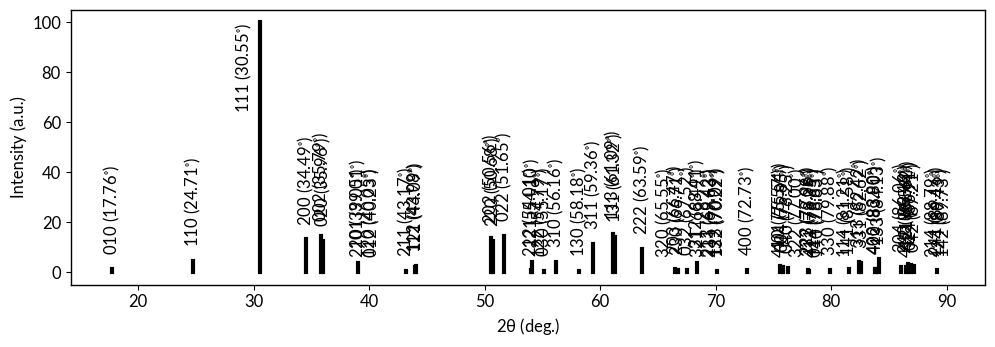

In [5]:
fig = crystal_u.get_xrd_pattern()

In [6]:
crystal_u.list_reflections()

  h   k   l     2θ (degrees)
-----------------------------------
  0   1   0        17.758408
  1   1   0        24.714259
  1   1   1        30.550152
  2   0   0        34.491276
  0   0   2        35.794334
  0   2   0        35.962238
  2   0   1        39.013939
  2   1   0        39.053001
  1   2   0        40.052306
  0   1   2        40.228691
  2   1   1        43.168582
  1   1   2        43.984655
  1   2   1        44.090824
  2   0   2        50.555233
  2   2   0        50.682542
  0   2   2        51.645453
  2   1   2        54.007090
  2   2   1        54.098253
  1   2   2        54.789716
  0   3   0        55.168881
  3   1   0        56.163215
  1   3   0        58.182687
  3   1   1        59.362183
  1   1   3        61.090476
  1   3   1        61.315055
  2   2   2        63.593404
  3   2   0        65.551059
  2   0   3        66.469564
  2   3   0        66.710829
  0   3   2        67.524946
  3   1   2        68.410715
  3   2   1        68.490063
  2   1

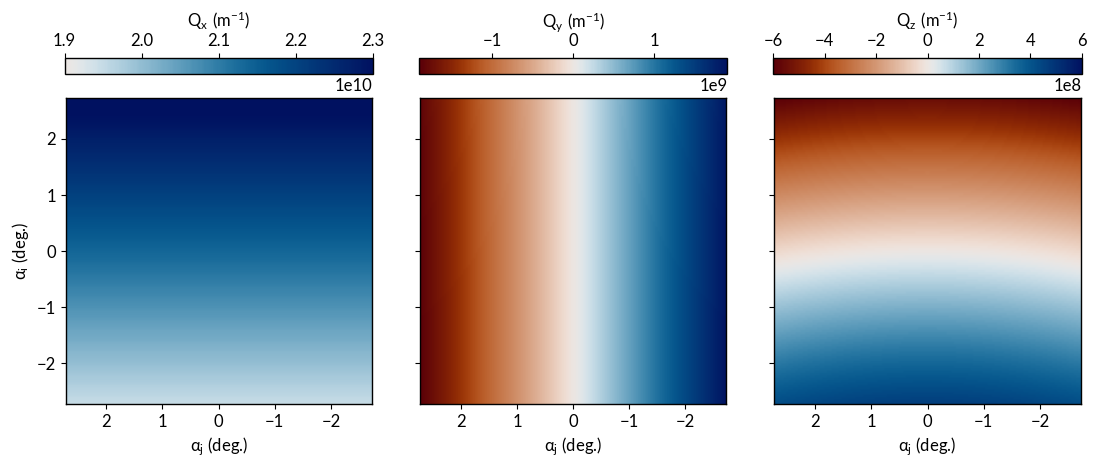

In [7]:
crystal_u.align_miller_plane_to_axis((1,1,1), target_axis='x')
crystal_d.align_miller_plane_to_axis((1,1,1), target_axis='x')

theta_B = torch.deg2rad(torch.tensor(30.55 / 2., dtype=dtype, device=device))
k_i = torch.tensor([torch.sin(-theta_B), 0.0, torch.cos(-theta_B)], dtype=dtype, device=device)
k_f = torch.tensor([torch.sin(theta_B), 0.0, torch.cos(theta_B)], dtype=dtype, device=device)

q_vectors = detector.calculate_q_vectors(k_i, k_f)
fig = detector.plot_q_vectors(q_vectors)

In [8]:
# Require that supercell approximation remains below experiment resolution, i.e. d_i * a_i < ΔX
print('ΔX:', ','.join('{:d}'.format(int(resolution / lengths[i].item())) for i in range(len(lengths))), 'cells')
print('ΔX^3:', '{:d}'.format(np.prod([int(resolution / lengths[i].item()) for i in range(len(lengths))])), 'cells')
print('Oversampling ratio:', detector.calculate_oversampling_ratio(crystal_u.crystal_volume).item())

ΔX: 3,3,3 cells
ΔX^3: 27 cells
Oversampling ratio: 3.4576239585876465


In [9]:
supercell_size = (2,2,2)
q_batch_size = 8

In [10]:
# Load exodus trajectory file
mesh = load_exodus("trajectories/HfO2.e")

In [11]:
# Resample fields to crystal grid
field = mesh.resample_to_crystal_grid(
    crystal_u,
    supercell_size = supercell_size,
    coord_scale = 1e-9,
    device = device,
    dtype = dtype
)

Crystal size (60, 60, 56) is 11.1 % smaller than the simulation box. Aligning top corner of crystal with top corner of simulation box. To override, pass an explicit anchor in exodus coordinates (1e-09 m units).


In [12]:
field

CrystalGrid(
  supercell grid         : 30 x 30 x 28
  time steps             : 737
  continuum_displacement : yes
  polarization           : yes
  lattice_strain         : yes
)

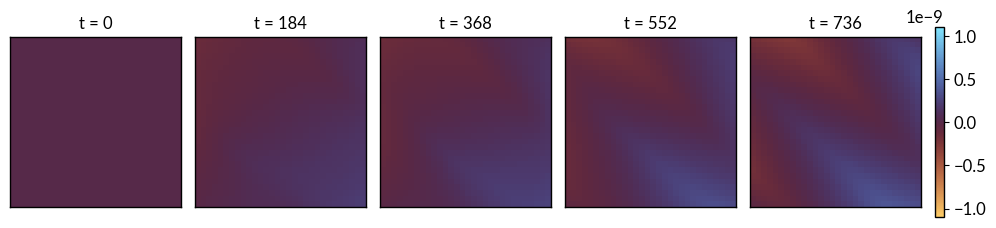

In [13]:
dim = 1
cmap = cm.managua
vmax = field.continuum_displacement[...,dim].abs().amax()
norm = plt.Normalize(vmin=-vmax, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(1,6, figsize=(10,2.5), gridspec_kw={'width_ratios':[1] * 5 + [0.05]})
fig.tight_layout()
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, timestep in enumerate(np.linspace(0, field.n_time_steps - 1, len(ax) - 1, dtype=int)):
    ax[i].imshow(field.continuum_displacement[timestep,:,:,field.continuum_displacement.shape[-2] // 2,dim].cpu(),
                 origin='lower', cmap=cmap, norm=norm)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    format_axis(ax[i], title=f't = {timestep}')

plt.colorbar(sm, cax=ax[-1])
format_axis(ax[-1])

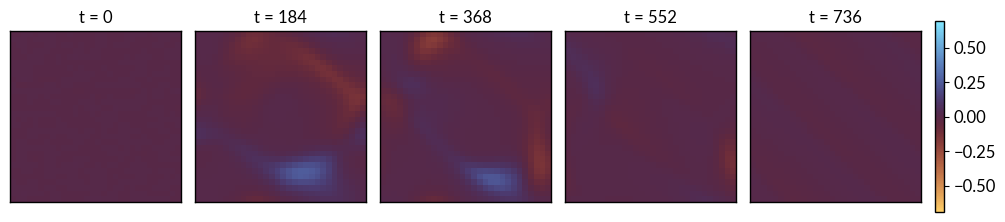

In [14]:
dim = 2
cmap = cm.managua
vmax = field.polarization[...,dim].abs().amax()
norm = plt.Normalize(vmin=-vmax, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(1,6, figsize=(10,2.5), gridspec_kw={'width_ratios':[1] * 5 + [0.05]})
fig.tight_layout()
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, timestep in enumerate(np.linspace(0, field.n_time_steps - 1, len(ax) - 1, dtype=int)):
    ax[i].imshow(field.polarization[timestep,:,:,field.polarization.shape[-2] // 2 + 1,dim].cpu(),
                 origin='lower', cmap=cmap, norm=norm)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    format_axis(ax[i], title=f't = {timestep}')

plt.colorbar(sm, cax=ax[-1])
format_axis(ax[-1])

In [15]:
beam = GaussianBeam(
    wavelength = wavelength,
    fwhm = 20e-9,
    device = device
)

beam.create_profile(
    crystal = crystal_u,
    supercell_size = supercell_size,
    k_i = k_i
)

Auto beam entry: crystal +a face, 
Beam_center: (59.0, 30.0, 28.0)


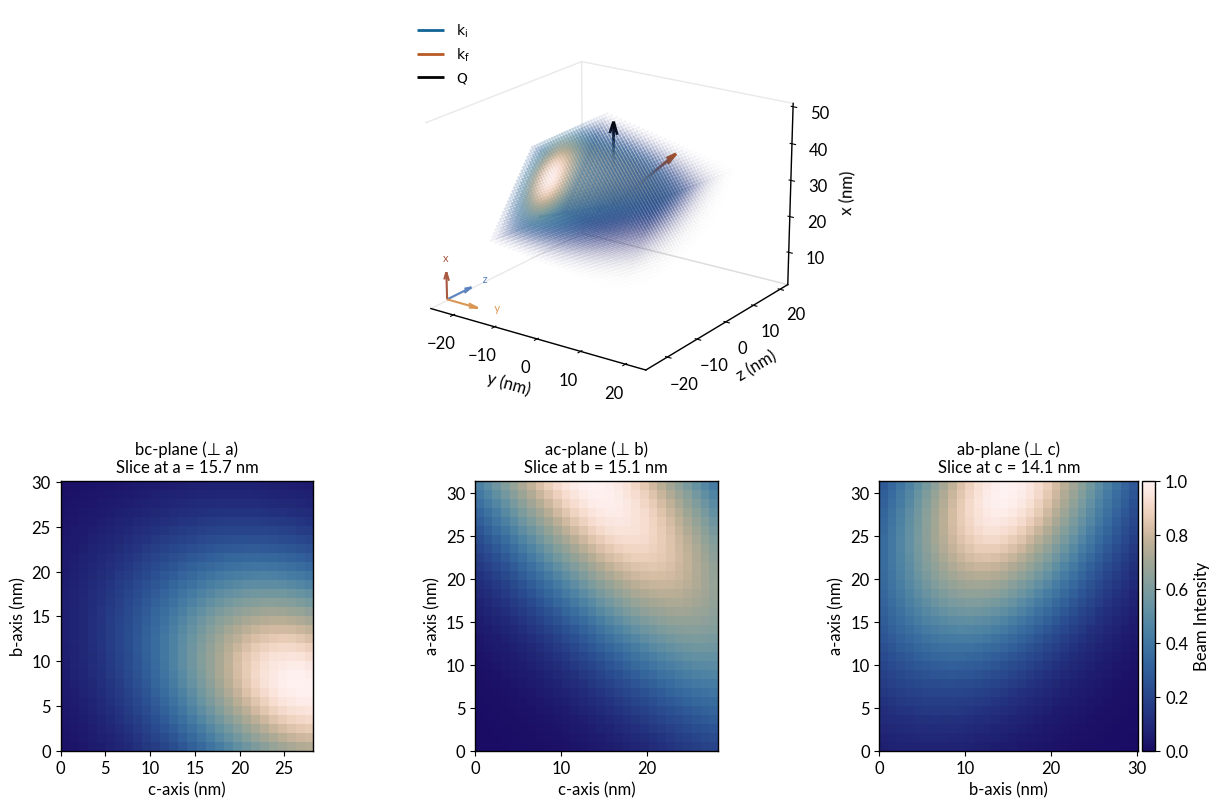

In [16]:
fig = beam.plot_profile(
    crystal = crystal_u,
    supercell_size = supercell_size,
    k_i = k_i,
    k_f = k_f,
    alpha_scale=0.8
)

In [17]:
simulator_u = BraggCoherentDiffraction(
    crystal = crystal_u,
    dtype = dtype,
    device = device
)

simulator_d = BraggCoherentDiffraction(
    crystal = crystal_d,
    dtype = dtype,
    device = device
)

In [18]:
# Create masks for positive and negative polar phases
polar_z_mask_u = F.sigmoid(field.polarization[...,2])
polar_z_mask_d = F.sigmoid(-field.polarization[...,2])

Execution time 1.9182214736938477 s


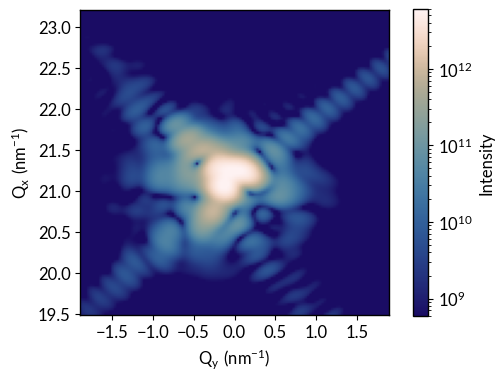

In [24]:
# Calculate intensity for a single timestep
timestep = 200
t_start = time.time()
amplitude = simulator_u.calculate_supercell_scattering(q_vectors, supercell_size, q_batch_size=q_batch_size,
                                                       continuum_displacement=field.continuum_displacement[[timestep]],
                                                       mask=beam.profile * polar_z_mask_u[[timestep]]) + \
            simulator_d.calculate_supercell_scattering(q_vectors, supercell_size, q_batch_size=q_batch_size,
                                                       continuum_displacement=field.continuum_displacement[[timestep]],
                                                       mask=beam.profile * polar_z_mask_d[[timestep]])
intensity = (amplitude.abs() ** 2)
print('Execution time', time.time() - t_start, 's')
fig = detector.plot_intensity(intensity[-1], q_vectors)

Execution time 69.2372887134552 s


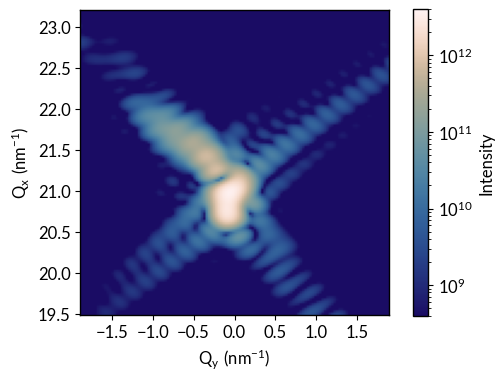

In [20]:
# Calculate intensity for all timesteps
t_start = time.time()
amplitude = simulator_u.calculate_supercell_scattering(q_vectors, supercell_size, q_batch_size=q_batch_size,
                                                       continuum_displacement=field.continuum_displacement,
                                                       mask=beam.profile * polar_z_mask_u) + \
            simulator_d.calculate_supercell_scattering(q_vectors, supercell_size, q_batch_size=q_batch_size,
                                                       continuum_displacement=field.continuum_displacement,
                                                       mask=beam.profile * polar_z_mask_d)
intensity = (amplitude.abs() ** 2)
print('Execution time', time.time() - t_start, 's')
fig = detector.plot_intensity(intensity[-1], q_vectors)

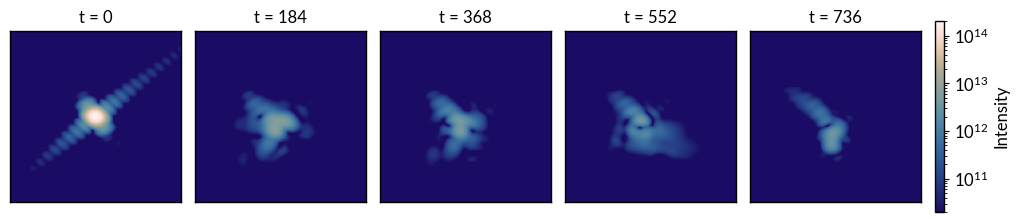

In [21]:
cmap = cm.lapaz
vmax = Detector.round_in_base(intensity[0].max().item(), digits=1)
vmin = vmax / 1e4 if vmax >= 1e4 else 1
norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax, clip=1)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(1,6, figsize=(10,2.5), gridspec_kw={'width_ratios':[1] * 5 + [0.05]})
fig.tight_layout()
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, timestep in enumerate(np.linspace(0, len(intensity)-1, len(ax) - 1, dtype=int)):
    ax[i].imshow(intensity[timestep].cpu(), origin='lower', cmap=cmap, norm=norm)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    format_axis(ax[i], title=f't = {timestep}')

plt.colorbar(sm, cax=ax[-1])
format_axis(ax[-1], ylabel='Intensity')

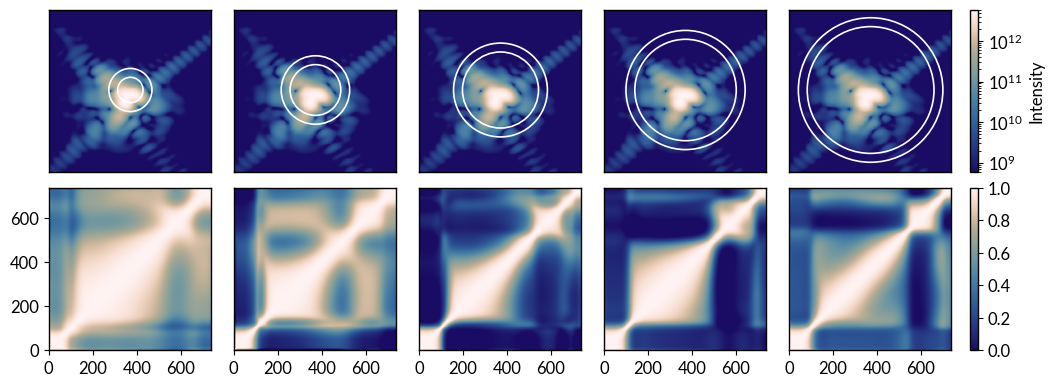

In [22]:
timestep = 200 # Timestep used to visualize annulus masks
cmap = cm.lapaz
vmax = Detector.round_in_base(intensity[timestep].max().item(), digits=1)
vmin = vmax / 1e4 if vmax >= 1e4 else 1
norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax, clip=1)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

norm_c2 = plt.Normalize(vmin=0., vmax=1.)
sm_c2 = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_c2)

fig, ax = plt.subplots(2,6, figsize=(10,4), gridspec_kw={'width_ratios':[1] * 5 + [0.05]})
fig.tight_layout()
fig.subplots_adjust(hspace=0.1, wspace=0.1)

radii = intensity.shape[-1] // 2 // 6 * np.arange(1,6)
width = 7
for i in range(ax.shape[1] - 1):
    roi = create_annulus_mask(*intensity.shape[1:], radii[i], width)
    
    ax[0,i].imshow(intensity[timestep].cpu(), origin='lower', cmap=cmap, norm=norm)
    draw_annulus_mask(
        ax[0,i],
        r_inner=radii[i],
        width=width,
        center=(intensity.shape[1] // 2,intensity.shape[2] // 2),
        lw=1.2,
        color="white",
    )
    
    ax[0,i].set_xticks([])
    ax[0,i].set_yticks([])
    
    C2 = calculate_two_time_correlation(intensity[:,roi].flatten(start_dim=1))
    ax[1,i].imshow(C2.cpu(), origin='lower', interpolation='none', cmap=cmap, norm=norm_c2)
    format_axis(ax[1,i], xbins=5, ybins=5)
    if i > 0:
        ax[1,i].set_yticks([])

plt.colorbar(sm, cax=ax[0,-1])
format_axis(ax[0,-1], ylabel='Intensity')

plt.colorbar(sm_c2, cax=ax[1,-1])
format_axis(ax[1,-1])

In [66]:
from matplotlib.animation import FuncAnimation, PillowWriter

def animate_intensity(intensity, xpcs, q_vectors = None,
                      vmin: float = None, vmax: float = None,
                      fps: int = 10, output_path: str = "intensity.gif") -> FuncAnimation:
    """
    Animate the intensity for each detector pixel across frames and save as a GIF.
    
    Parameters:
    -----------
    intensity: torch.Tensor
        Scattered intensity as a tensor of shape [num_frames, num_pixels_i, num_pixels_j]
    xpcs: torch.Tensor
        Static XPCS image as a tensor of shape [num_pixels_i, num_pixels_j]
    q_vectors: torch.Tensor
        q vectors for each pixel as a tensor of shape [num_pixels_i, num_pixels_j, 3]
    vmin: float
        Minimum of the data range for the intensity colormap
    vmax: float
        Maximum of the data range for the intensity colormap
    fps: int
        Frames per second for the output GIF
    output_path: str
        File path for the saved GIF
        
    Returns:
    --------
    matplotlib.animation.FuncAnimation:
        The resulting animation object
    """
    vmax = vmax if vmax is not None else Detector.round_in_base(intensity.max().item(), digits=1)
    vmin = vmin if vmin is not None else vmax / 1e4

    cmap = cm.lapaz

    # Intensity (log scale)
    norm_intensity = mpl.colors.LogNorm(vmin=vmin, vmax=vmax, clip=True)
    sm_intensity = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_intensity)

    # XPCS (linear 0-1)
    norm_xpcs = mpl.colors.Normalize(vmin=0, vmax=1, clip=True)
    sm_xpcs = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_xpcs)

    if q_vectors is not None:
        extent = [k.cpu() * 1e-9 for k in [q_vectors[0,0,1], q_vectors[0,-1,1], q_vectors[0,0,0], q_vectors[-1,0,0]]]
        xlabel, ylabel = r'$Q_y\ (nm^{-1})$', r'$Q_x\ (nm^{-1})$'
    else:
        extent = None
        xlabel, ylabel = 'Pixels', 'Pixels'

    fig, axes = plt.subplots(2, 2, figsize=(8,5), gridspec_kw={'height_ratios': [0.05, 1]})
    cax_intensity, cax_xpcs = axes[0, 0], axes[0, 1]
    ax_intensity, ax_xpcs   = axes[1, 0], axes[1, 1]

    # Colorbars — use xlabel so the label sits along the horizontal axis
    plt.colorbar(sm_intensity, cax=cax_intensity, orientation='horizontal')
    plt.colorbar(sm_xpcs,      cax=cax_xpcs,      orientation='horizontal')
    
    for cax in [cax_intensity, cax_xpcs]:
        cax.xaxis.set_ticks_position('top')
        cax.xaxis.set_label_position('top')
        
    format_axis(cax_intensity, xlabel='Intensity')
    format_axis(cax_xpcs,      xlabel='XPCS')
        
    # Animated intensity (bottom left)
    im = ax_intensity.imshow(intensity[0].cpu(), origin='lower', cmap=cmap, norm=norm_intensity, extent=extent)
    format_axis(ax_intensity, xlabel=xlabel, ylabel=ylabel, xbins=4, ybins=4)

    # Static XPCS (bottom right) — axes are time, not Q
    n_frames = len(intensity)
    ax_xpcs.imshow(xpcs.cpu(), origin='lower', cmap=cmap, norm=norm_xpcs)
    format_axis(ax_xpcs, xlabel=r'$t_1$', ylabel=r'$t_2$', xbins=4, ybins=4)

    # Initialise lines at frame 0 — both collapsed to the origin
    line_h, = ax_xpcs.plot([0, 0], [0, 0], color='black', linewidth=1)  # horizontal
    line_v, = ax_xpcs.plot([0, 0], [0, 0], color='black', linewidth=1)  # vertical

    fig.tight_layout()

    def update(frame_idx):
        im.set_data(intensity[frame_idx].cpu())
        # Horizontal: y=frame_idx, x from 0 → frame_idx
        line_h.set_data([0, frame_idx], [frame_idx, frame_idx])
        # Vertical:   x=frame_idx, y from 0 → frame_idx
        line_v.set_data([frame_idx, frame_idx], [0, frame_idx])
        return im, line_h, line_v

    anim = FuncAnimation(fig, update, frames=len(intensity), blit=True, interval=1000 // fps)
    anim.save(output_path, writer=PillowWriter(fps=fps))
    plt.close(fig)

    return anim

In [ ]:
roi = create_annulus_mask(*intensity.shape[1:], 30, 5)
xpcs = calculate_two_time_correlation(intensity[:,roi].flatten(start_dim=1))

In [67]:
animate_intensity(
    intensity,
    xpcs,
    q_vectors,
    vmin = 1e9,
    vmax = 1e13,
    fps = 60,
    output_path = "xpcs.gif"
);